# Task 3c: Transfer Learning with GoogLeNet

### Setup Imports

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import GoogLeNet_Weights
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

### Load Fruit Dataset

In [2]:
# Data transforms - GoogLeNet uses 224x224
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # GoogLeNet input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset
dataset = ImageFolder('FruitData', transform=transform)
train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Load GoogLeNet and Modify Classifier

In [3]:
# Load pre-trained GoogLeNet
model = torchvision.models.googlenet(pretrained=True)

# Modify the classifier
num_classes = 5
model.fc = torch.nn.Linear(1024, num_classes)  # GoogLeNet's final layer has 1024 features
model = model.to(device)

/opt/homebrew/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Training Loop

In [ ]:
# Training parameters
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
num_epochs = 10

# Lists to store metrics
train_losses = []
val_accuracies = []
val_losses = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        # GoogLeNet returns auxiliary outputs during training
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    # Calculate epoch loss
    epoch_loss = running_loss/len(train_loader)
    train_losses.append(epoch_loss)
    
    # Validation accuracy
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_epoch_loss = val_loss/len(val_loader)
    val_accuracy = 100 * correct / total
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_accuracy)
    
    print(f'Epoch {epoch+1}:')
    print(f'  Training Loss: {epoch_loss:.4f}')
    print(f'  Validation Loss: {val_epoch_loss:.4f}')
    print(f'  Validation Accuracy: {val_accuracy:.2f}%')
    print('-' * 60)

Epoch 1:
  Training Loss: 1.6392
  Validation Loss: 1.5639
  Validation Accuracy: 39.13%
------------------------------------------------------------
Epoch 2:
  Training Loss: 1.4326
  Validation Loss: 1.4548
  Validation Accuracy: 47.83%
------------------------------------------------------------
Epoch 3:
  Training Loss: 1.1561
  Validation Loss: 1.2880
  Validation Accuracy: 56.52%
------------------------------------------------------------
Epoch 4:
  Training Loss: 0.8058
  Validation Loss: 1.1097
  Validation Accuracy: 65.22%
------------------------------------------------------------
Epoch 5:
  Training Loss: 0.5391
  Validation Loss: 0.9210
  Validation Accuracy: 82.61%
------------------------------------------------------------
Epoch 6:
  Training Loss: 0.3241
  Validation Loss: 0.7739
  Validation Accuracy: 86.96%
------------------------------------------------------------
Epoch 7:
  Training Loss: 0.2150
  Validation Loss: 0.6679
  Validation Accuracy: 91.30%
-----------

### Final Evaluation

Final Test Accuracy: 86.95652173913044%


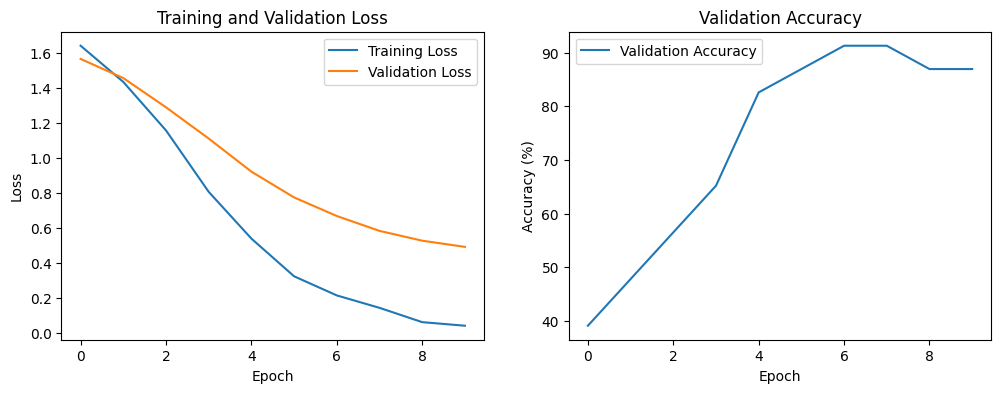

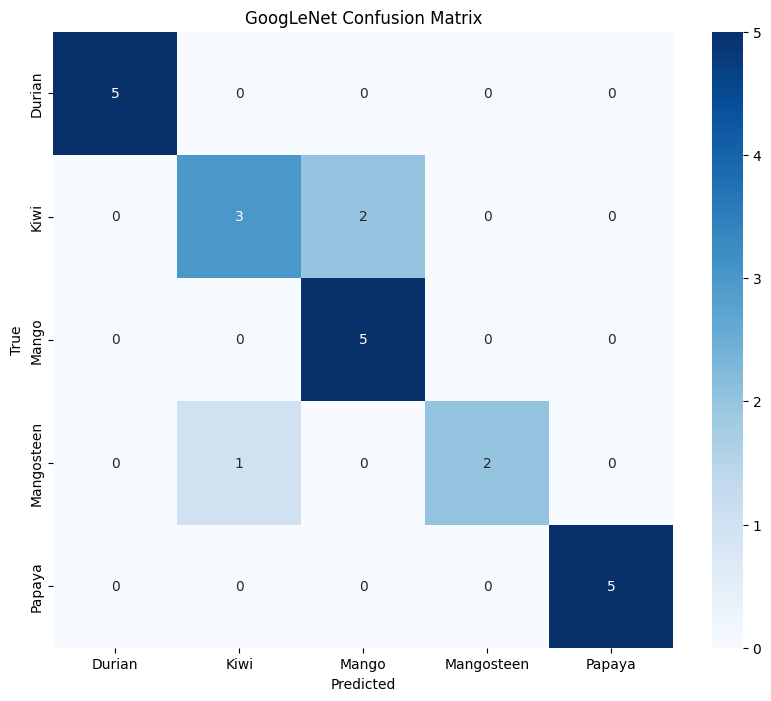

In [5]:
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

final_accuracy = 100 * correct / total
print(f'Final Test Accuracy: {final_accuracy}%')

# Plot training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Validation Accuracy')
plt.show()

# Plot confusion matrix (on a new figure)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=dataset.classes, 
            yticklabels=dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('GoogLeNet Confusion Matrix')
plt.show()

# Save the model
torch.save(model.state_dict(), 'googlenet_fruits.pth')